#Project 2:Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

##Abstract

AI-generated image detectors are typically evaluated under idealized conditions, where im-
ages are clean, uncompressed, and sourced directly from generative models. In practice, however, images

circulating on social media have almost always undergone some form of post-processing each of which in-
troduces a distinct degradation signature that can disrupt detector performance. This project proposes a

unified multi-task deep learning framework that simultaneously addresses two forensic questions: whether
an image is real or AI-generated, and which type of post-processing alteration has been applied to it. A
further analytical objective investigates whether AI-generated and real images respond differently to the
same post-processing operations, potentially revealing exploitable cross-class traces that can inform more
robust detection strategies.




##Dataset

RRDataset: a real-world robustness benchmark containing real photographs and AI-generated images
with three splits: original, internet-transmitted, and re-digitized. Students may select a subset of the dataset,
comprehensive of all three classes, according to their available hardware.

##Task

Given a single input image, a unified deep learning model must produce two predictions simultaneously: (1)
a binary real/fake label indicating whether the image is a genuine photograph or AI-generated, and (2) a multi-class
transformation label indicating which post-processing alteration has been applied (original, internet-transmitted, or
re-digitalized). Both predictions are produced by a shared backbone, trained jointly with a combined loss function.
The project is structured in three phases: baseline unimodal training, joint multi-task training, and an analytical
phase investigating cross-class transformation traces.

##Main objectives

• Data preparation and subset selection: Download and preprocess the RRDataset, constructing a balanced split across real/fake classes and transformation categories. Students should document their hardware-driven subset choice and verify class balance before training.

• Multi-task unified model: Implement a shared backbone with two independent classification heads, one per task. Train the model jointly using a weighted combination of the two cross-entropy losses, and experiment with different loss weighting strategies. Evaluate both tasks simultaneously and compare against the unimodal baselines to assess whether joint training improves, degrades, or leaves unchanged the performance of each individual task.

• Performance analysis across transformation types: Break down real/fake detection accuracy separately for

each transformation category, original, transmitted, and each re-digitization method, to identify which post- processing operations are most damaging to detection performance and whether the pattern differs between

real and AI-generated images.

• Ablation study: Analyze how different weightings of the two task losses affect the trade-off between real/fake

accuracy and transformation classification accuracy, identifying whether the two tasks compete for represen- tational capacity or complement each other.

##References


• Li, Chunxiao, et al. ”Bridging the Gap Between Ideal and Real-world Evaluation: Benchmarking AI-Generated
Image Detection in Challenging Scenarios.” Proceedings of the IEEE/CVF International Conference on Com-
puter Vision. 2025. https://openaccess.thecvf.com/content/ICCV2025/papers/Li_Bridging_the_Gap_Between_Ideal_and_Real-world_Evaluation_Benchmarking_AI-Generated_ICCV_2025_paper.pdf



• Shao, Rui, Tianxing Wu, and Ziwei Liu. ”Detecting and grounding multi-modal media manipulation.” Pro-
ceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition. 2023. https://arxiv.org/pdf/2304.02556

#Imports


In [1]:
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

#Globals


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- CONFIGURAZIONE PERCORSI ---
DRIVE_PATH = '/content/drive/MyDrive/CV' # Cambia con la tua cartella Drive
LOCAL_EXTRACT_PATH = '/content/dataset_raw'
SUBSET_PATH = '/content/dataset_subset'
ZIP_NAME = 'RRDataset_test.tar.gz'

#Utils

##Dataset's upload on Drive

In [4]:
# 1. Estrazione (Eseguila solo se le cartelle non esistono)
def prepare_data():

    # 1. Pulizia cartelle precedenti per evitare conflitti

    if os.path.exists(LOCAL_EXTRACT_PATH):

        shutil.rmtree(LOCAL_EXTRACT_PATH)

    os.makedirs(LOCAL_EXTRACT_PATH)



    # 2. Estrazione del file unico

    tar_path = os.path.join(DRIVE_PATH, ZIP_NAME)

    if os.path.exists(tar_path):

        print(f"Estrazione in corso di {ZIP_NAME}...")

        !tar -xzf {tar_path} -C {LOCAL_EXTRACT_PATH}

        print("Estrazione completata.")

    else:

        print(f"ERRORE: Non trovo il file {ZIP_NAME} in {DRIVE_PATH}")



prepare_data()

# Verifica rapida della struttura estratta
print("\nStruttura cartelle rilevata:")
!find {LOCAL_EXTRACT_PATH} -maxdepth 2 -type d

ERRORE: Non trovo il file RRDataset_test.tar.gz in /content/drive/MyDrive/CV

Struttura cartelle rilevata:
/content/dataset_raw


##Subsampling

In [7]:
def get_balanced_subset(root_raw, n_per_comb=1000):
    # Struttura: trasformazione -> classe -> lista percorsi
    data_map = {
        'original': {'real': [], 'ai': []},
        'transfer': {'real': [], 'ai': []},
        'redigital': {'real': [], 'ai': []}
    }

    # Logica di ricerca file (adatta ai nomi delle tue cartelle estratte)
    # Cerchiamo ricorsivamente nelle cartelle appena estratte
    for root, dirs, files in os.walk(root_raw):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, f)
                # Determina trasformazione
                trans = None
                if 'original' in root.lower(): trans = 'original'
                elif 'transfer' in root.lower(): trans = 'transfer'
                elif 'redigital' in root.lower(): trans = 'redigital'

                # Determina classe
                rf = None
                if 'real' in root.lower(): rf = 'real'
                elif 'ai' in root.lower(): rf = 'ai'

                if trans and rf:
                    data_map[trans][rf].append(full_path)

    subset = []
    for trans in data_map:
        for rf in data_map[trans]:
            paths = data_map[trans][rf]
            selected = random.sample(paths, min(n_per_comb, len(paths)))
            for p in selected:
                subset.append({
                    'path': p,
                    'label_rf': 1 if rf == 'ai' else 0,
                    'label_trans': {'original': 0, 'transfer': 1, 'redigital': 2}[trans],
                    'trans_name': trans
                })
    return subset

balanced_list = get_balanced_subset(LOCAL_EXTRACT_PATH)
print(f"Subset creato: {len(balanced_list)} immagini totali.")

Subset creato: 0 immagini totali.


#Data

In [6]:
class RRMultiTaskDataset(Dataset):
    def __init__(self, data_list, transform=None, filter_trans=None):
        # Se filter_trans è 'original', carichiamo solo quelle per la Baseline
        if filter_trans:
            self.data = [x for x in data_list if x['trans_name'] == filter_trans]
        else:
            self.data = data_list
        self.transform = transform

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img = Image.open(item['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, item['label_rf'], item['label_trans']
# Augmentation forte per combattere l'overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Creazione DataLoader per BASELINE (Solo Original)
baseline_ds = RRMultiTaskDataset(balanced_list, transform=train_transform, filter_trans='original')
baseline_loader = DataLoader(baseline_ds, batch_size=32, shuffle=True)

# Creazione DataLoader per MULTI-TASK (Tutti)
multitask_ds = RRMultiTaskDataset(balanced_list, transform=train_transform)
multitask_loader = DataLoader(multitask_ds, batch_size=32, shuffle=True)


ValueError: num_samples should be a positive integer value, but got num_samples=0

#Network

In [ ]:
class MultiTaskEffNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        num_ftrs = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.head_rf = nn.Linear(num_ftrs, 2)    # Task 1: Real/Fake
        self.head_trans = nn.Linear(num_ftrs, 3) # Task 2: 3 Trasformazioni

    def forward(self, x):
        f = self.backbone(x)
        return self.head_rf(f), self.head_trans(f)

#Train

##Baseline unimodal training

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s]


Inizio Training Baseline (Task: Real/Fake su Original)...
Epoch 1/10 -> Train Acc: 0.7857 | Val Acc: 0.8444
Epoch 2/10 -> Train Acc: 0.9155 | Val Acc: 0.8673
Epoch 3/10 -> Train Acc: 0.9520 | Val Acc: 0.8650
Epoch 4/10 -> Train Acc: 0.9661 | Val Acc: 0.8764
Epoch 5/10 -> Train Acc: 0.9667 | Val Acc: 0.8719
Epoch 6/10 -> Train Acc: 0.9648 | Val Acc: 0.8444
Epoch 7/10 -> Train Acc: 0.9789 | Val Acc: 0.8650
Epoch 8/10 -> Train Acc: 0.9827 | Val Acc: 0.8627
Epoch 9/10 -> Train Acc: 0.9891 | Val Acc: 0.8673
Epoch 10/10 -> Train Acc: 0.9750 | Val Acc: 0.8627


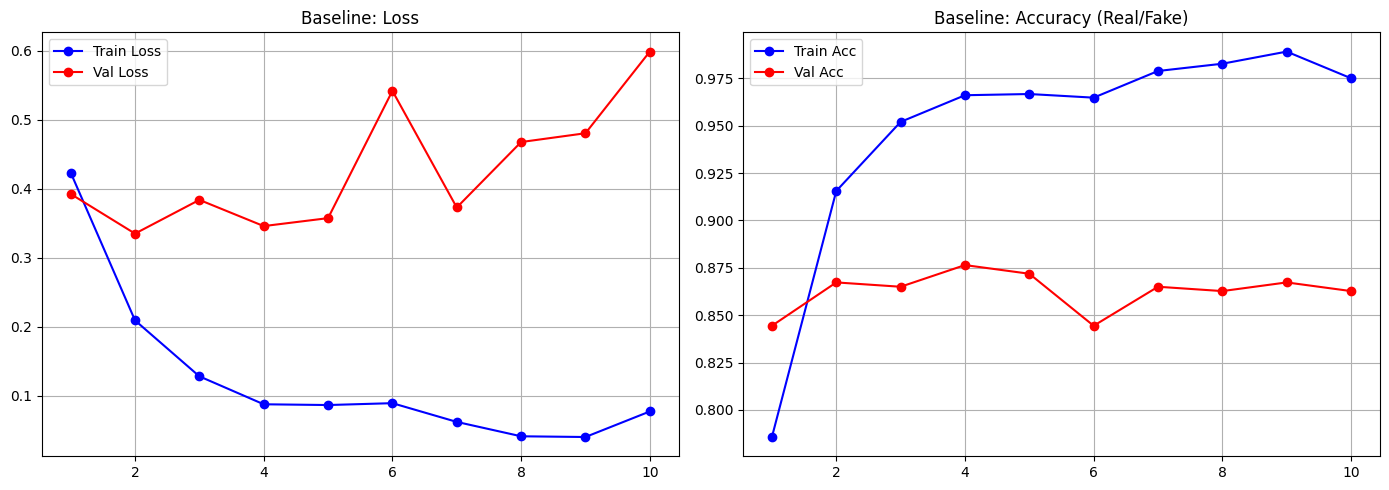

In [ ]:
def train_baseline(model, loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Ottimizzatore con Weight Decay per combattere l'overfitting
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        # --- PHASE: TRAIN ---
        for imgs, labels_rf, _ in loader: # Ignoriamo labels_trans
            imgs, labels_rf = imgs.to(device), labels_rf.to(device)

            optimizer.zero_grad()
            out_rf, _ = model(imgs) # Ignoriamo la seconda testa

            loss = criterion(out_rf, labels_rf)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(out_rf, 1)
            running_loss += loss.item() * imgs.size(0)
            running_corrects += torch.sum(preds == labels_rf.data)

        epoch_loss = running_loss / len(loader.dataset)
        epoch_acc = running_corrects.double() / len(loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        # --- PHASE: VALIDATION ---
        model.eval()
        v_loss, v_corrects = 0.0, 0
        with torch.no_grad():
            for imgs, labels_rf, _ in val_loader:
                imgs, labels_rf = imgs.to(device), labels_rf.to(device)
                out_rf, _ = model(imgs)
                loss = criterion(out_rf, labels_rf)

                _, preds = torch.max(out_rf, 1)
                v_loss += loss.item() * imgs.size(0)
                v_corrects += torch.sum(preds == labels_rf.data)

        val_loss = v_loss / len(val_loader.dataset)
        val_acc = v_corrects.double() / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f"Epoch {epoch+1}/{epochs} -> Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

        # Salvataggio del miglior modello
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_baseline_v2.pth')

    return model, history


def plot_baseline_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    plt.title('Baseline: Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
    plt.title('Baseline: Accuracy (Real/Fake)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('plot_baseline.png')
    plt.show()

# Esempio d'uso: plot_baseline_history(history_base)


from sklearn.model_selection import train_test_split

# Dividiamo la lista bilanciata (80% train, 20% val)
train_list, val_list = train_test_split(balanced_list, test_size=0.2, random_state=42)

# DataLoader Baseline (Solo Original)
train_ds_base = RRMultiTaskDataset(train_list, transform=train_transform, filter_trans='original')
val_ds_base = RRMultiTaskDataset(val_list, transform=train_transform, filter_trans='original')

baseline_train_loader = DataLoader(train_ds_base, batch_size=32, shuffle=True)
baseline_val_loader = DataLoader(val_ds_base, batch_size=32, shuffle=False)

# Inizializza Modello
model_baseline = MultiTaskEffNet()

# Avvia Training Baseline
print("Inizio Training Baseline (Task: Real/Fake su Original)...")
model_baseline, history_base = train_baseline(model_baseline, baseline_train_loader, baseline_val_loader, epochs=10)

# --- PLOT RISULTATI BASELINE ---
# Usa questo comando per visualizzare i grafici appena finito il training
plot_baseline_history(history_base)

##Joint multi-task training


--- Training Multi-Task (Alpha 0.5) ---
Ep 1 | Loss: 0.432 | RF Acc: 0.8683 | Trans Acc: 0.7683
Ep 2 | Loss: 0.356 | RF Acc: 0.8958 | Trans Acc: 0.8075
Ep 3 | Loss: 0.386 | RF Acc: 0.8900 | Trans Acc: 0.7983
Ep 4 | Loss: 0.348 | RF Acc: 0.8925 | Trans Acc: 0.8425
Ep 5 | Loss: 0.349 | RF Acc: 0.9008 | Trans Acc: 0.8358
Ep 6 | Loss: 0.378 | RF Acc: 0.9050 | Trans Acc: 0.8183
Ep 7 | Loss: 0.431 | RF Acc: 0.8983 | Trans Acc: 0.8133
Ep 8 | Loss: 0.409 | RF Acc: 0.8992 | Trans Acc: 0.8142
Ep 9 | Loss: 0.442 | RF Acc: 0.8925 | Trans Acc: 0.8117
Ep 10 | Loss: 0.401 | RF Acc: 0.9075 | Trans Acc: 0.8317


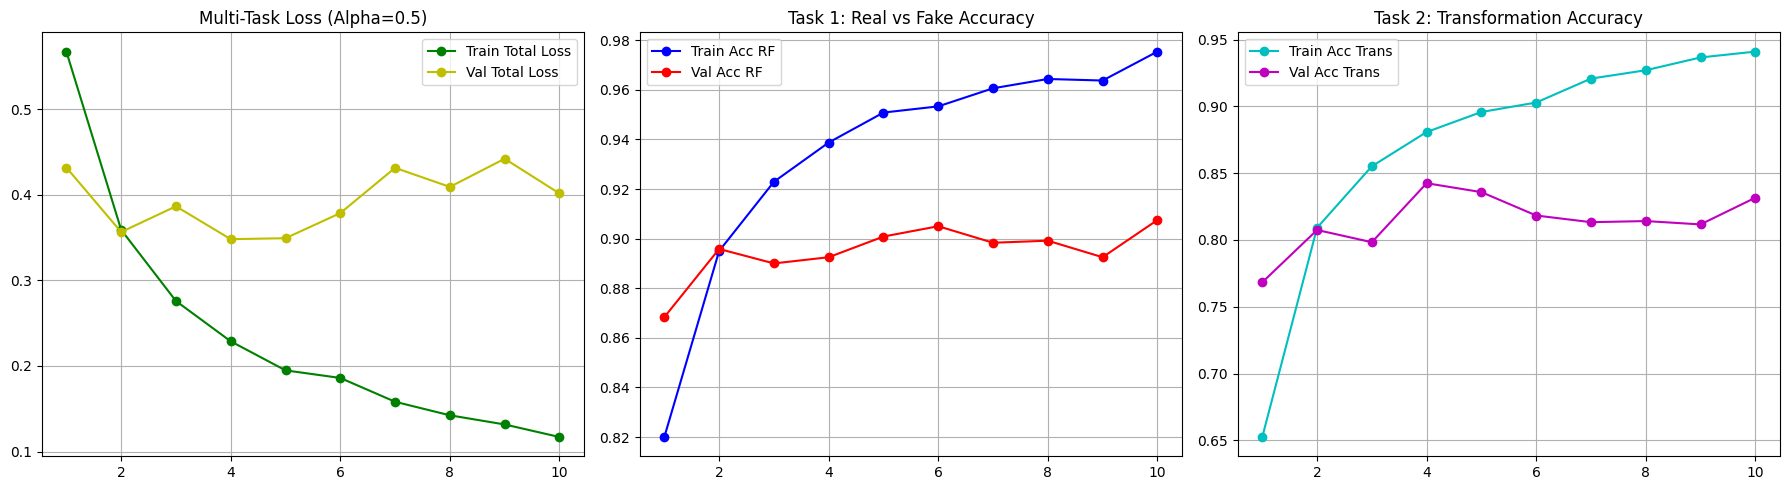


--- Training Multi-Task (Alpha 0.8) ---
Ep 1 | Loss: 0.375 | RF Acc: 0.8825 | Trans Acc: 0.6733
Ep 2 | Loss: 0.359 | RF Acc: 0.8858 | Trans Acc: 0.7383
Ep 3 | Loss: 0.328 | RF Acc: 0.8942 | Trans Acc: 0.7650
Ep 4 | Loss: 0.337 | RF Acc: 0.9000 | Trans Acc: 0.7658
Ep 5 | Loss: 0.342 | RF Acc: 0.9033 | Trans Acc: 0.7867
Ep 6 | Loss: 0.334 | RF Acc: 0.9108 | Trans Acc: 0.7858
Ep 7 | Loss: 0.303 | RF Acc: 0.9125 | Trans Acc: 0.7758
Ep 8 | Loss: 0.402 | RF Acc: 0.9075 | Trans Acc: 0.8000
Ep 9 | Loss: 0.355 | RF Acc: 0.9100 | Trans Acc: 0.8033
Ep 10 | Loss: 0.359 | RF Acc: 0.9000 | Trans Acc: 0.7950


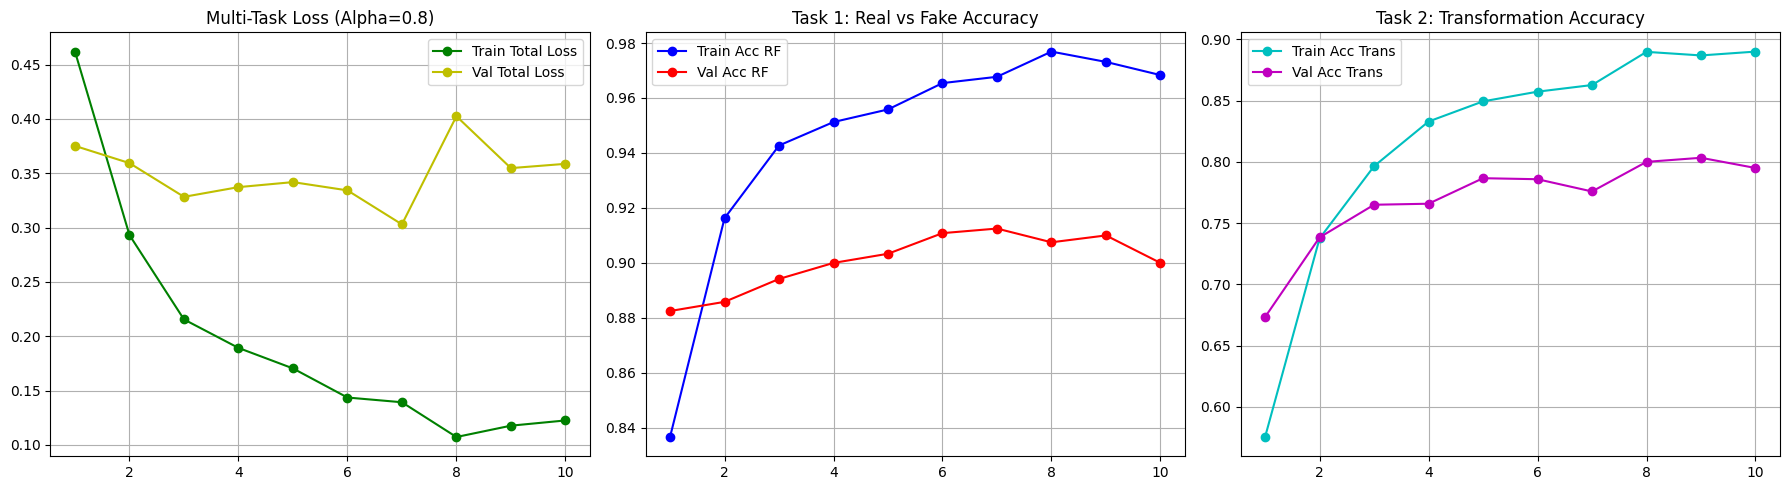

In [ ]:
def train_multitask(model, train_loader, val_loader, epochs=10, alpha=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc_rf': [], 'val_acc_rf': [],
        'train_acc_trans': [], 'val_acc_trans': []
    }
    best_acc_rf = 0.0

    for epoch in range(epochs):
        model.train()
        r_loss = 0.0
        correct_rf, correct_trans = 0, 0

        for imgs, labels_rf, labels_trans in train_loader:
            imgs, labels_rf, labels_trans = imgs.to(device), labels_rf.to(device), labels_trans.to(device)

            optimizer.zero_grad()
            out_rf, out_trans = model(imgs)

            loss_rf = criterion(out_rf, labels_rf)
            loss_trans = criterion(out_trans, labels_trans)

            # Calcolo Loss Combinata
            total_loss = (alpha * loss_rf) + ((1 - alpha) * loss_trans)

            total_loss.backward()
            optimizer.step()

            r_loss += total_loss.item() * imgs.size(0)
            _, pred_rf = torch.max(out_rf, 1)
            _, pred_trans = torch.max(out_trans, 1)
            correct_rf += torch.sum(pred_rf == labels_rf.data)
            correct_trans += torch.sum(pred_trans == labels_trans.data)

        # Metriche Training
        epoch_loss = r_loss / len(train_loader.dataset)
        acc_rf = correct_rf.double() / len(train_loader.dataset)
        acc_trans = correct_trans.double() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc_rf'].append(acc_rf.item())
        history['train_acc_trans'].append(acc_trans.item())

        # --- VALIDATION ---
        model.eval()
        v_loss, v_corr_rf, v_corr_trans = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels_rf, labels_trans in val_loader:
                imgs, labels_rf, labels_trans = imgs.to(device), labels_rf.to(device), labels_trans.to(device)

                out_rf, out_trans = model(imgs)
                loss_rf = criterion(out_rf, labels_rf)
                loss_trans = criterion(out_trans, labels_trans)
                total_v_loss = (alpha * loss_rf) + ((1 - alpha) * loss_trans)

                v_loss += total_v_loss.item() * imgs.size(0)
                _, p_rf = torch.max(out_rf, 1)
                _, p_trans = torch.max(out_trans, 1)
                v_corr_rf += torch.sum(p_rf == labels_rf.data)
                v_corr_trans += torch.sum(p_trans == labels_trans.data)

        val_loss = v_loss / len(val_loader.dataset)
        v_acc_rf = v_corr_rf.double() / len(val_loader.dataset)
        v_acc_trans = v_corr_trans.double() / len(val_loader.dataset)

        history['val_loss'].append(val_loss)
        history['val_acc_rf'].append(v_acc_rf.item())
        history['val_acc_trans'].append(v_acc_trans.item())

        print(f"Ep {epoch+1} | Loss: {val_loss:.3f} | RF Acc: {v_acc_rf:.4f} | Trans Acc: {v_acc_trans:.4f}")

        if v_acc_rf > best_acc_rf:
            best_acc_rf = v_acc_rf
            torch.save(model.state_dict(), f'best_multitask_alpha_{alpha}.pth')

    return model, history


def plot_multitask_history(history, alpha):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(18, 5))

    # 1. Total Loss (Pesata con Alpha)
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], 'g-o', label='Train Total Loss')
    plt.plot(epochs, history['val_loss'], 'y-o', label='Val Total Loss')
    plt.title(f'Multi-Task Loss (Alpha={alpha})')
    plt.legend()
    plt.grid(True)

    # 2. Accuracy Real/Fake
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc_rf'], 'b-o', label='Train Acc RF')
    plt.plot(epochs, history['val_acc_rf'], 'r-o', label='Val Acc RF')
    plt.title('Task 1: Real vs Fake Accuracy')
    plt.legend()
    plt.grid(True)

    # 3. Accuracy Trasformazione
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_acc_trans'], 'c-o', label='Train Acc Trans')
    plt.plot(epochs, history['val_acc_trans'], 'm-o', label='Val Acc Trans')
    plt.title('Task 2: Transformation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'plot_multitask_alpha_{alpha}.png')
    plt.show()

# Esempio d'uso: plot_multitask_history(history_05, 0.5)


# 1. Prepara i DataLoader Multi-Task (usano TUTTE le immagini del subset)
mt_train_ds = RRMultiTaskDataset(train_list, transform=train_transform)
mt_val_ds = RRMultiTaskDataset(val_list, transform=train_transform)

mt_train_loader = DataLoader(mt_train_ds, batch_size=32, shuffle=True)
mt_val_loader = DataLoader(mt_val_ds, batch_size=32, shuffle=False)

# 2. ESPERIMENTO A: Bilanciamento Equo (Alpha = 0.5)
print("\n--- Training Multi-Task (Alpha 0.5) ---")
model_mt_05 = MultiTaskEffNet()
# Carichiamo i pesi della baseline per dare un "vantaggio" al modello (opzionale)
# model_mt_05.load_state_dict(torch.load('best_baseline_v2.pth'), strict=False)

model_mt_05, history_05 = train_multitask(model_mt_05, mt_train_loader, mt_val_loader, epochs=10, alpha=0.5)

# --- PLOT RISULTATI MULTI-TASK (ALPHA 0.5) ---
# Mostra tre grafici: Loss totale, Acc Real/Fake, Acc Trasformazioni
plot_multitask_history(history_05, 0.5)

# 3. ESPERIMENTO B: Focus su Real/Fake (Alpha = 0.8)
print("\n--- Training Multi-Task (Alpha 0.8) ---")
model_mt_08 = MultiTaskEffNet()
model_mt_08, history_08 = train_multitask(model_mt_08, mt_train_loader, mt_val_loader, epochs=10, alpha=0.8)

# --- PLOT RISULTATI MULTI-TASK (ALPHA 0.8) ---
plot_multitask_history(history_08, 0.8)




--- Training Multi-Task (Alpha 0.2) ---
Ep 1 | Loss: 0.553 | RF Acc: 0.8367 | Trans Acc: 0.7558
Ep 2 | Loss: 0.420 | RF Acc: 0.8633 | Trans Acc: 0.8017
Ep 3 | Loss: 0.368 | RF Acc: 0.8858 | Trans Acc: 0.8408
Ep 4 | Loss: 0.374 | RF Acc: 0.8767 | Trans Acc: 0.8325
Ep 5 | Loss: 0.377 | RF Acc: 0.8808 | Trans Acc: 0.8450
Ep 6 | Loss: 0.434 | RF Acc: 0.8758 | Trans Acc: 0.8383
Ep 7 | Loss: 0.413 | RF Acc: 0.8717 | Trans Acc: 0.8400
Ep 8 | Loss: 0.449 | RF Acc: 0.8817 | Trans Acc: 0.8300
Ep 9 | Loss: 0.417 | RF Acc: 0.8850 | Trans Acc: 0.8483
Ep 10 | Loss: 0.438 | RF Acc: 0.8933 | Trans Acc: 0.8367


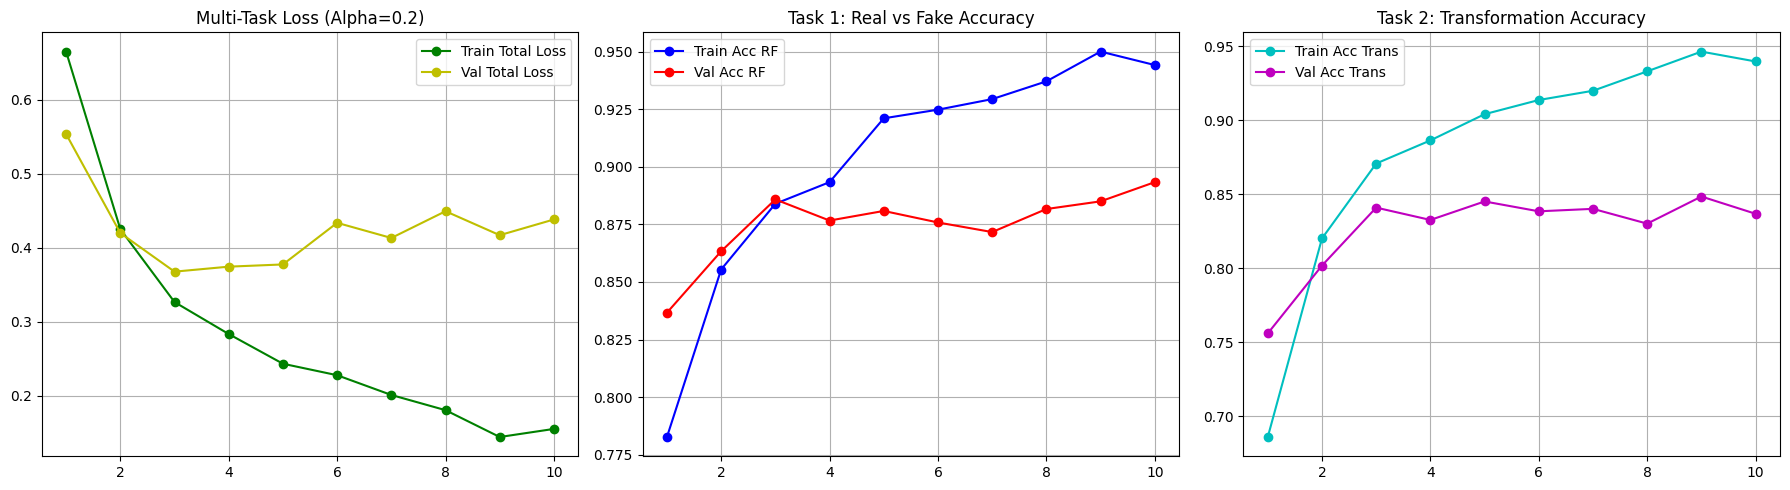

In [ ]:
# 3. ESPERIMENTO C: Focus su Trasformazioni (Alpha = 0.2)
print("\n--- Training Multi-Task (Alpha 0.2) ---")
model_mt_02 = MultiTaskEffNet()
model_mt_02, history_02 = train_multitask(model_mt_02, mt_train_loader, mt_val_loader, epochs=10, alpha=0.2)

# --- PLOT RISULTATI MULTI-TASK (ALPHA 0.2) ---
plot_multitask_history(history_02, 0.2)

# NOVELTY